# Prédiction de la Progression de la Maladie de Parkinson
## Exploration Visuelle & Exécution du Pipeline

---

> **Architecture du projet** — Ce notebook est un *orchestrateur visuel*.
> Toute la logique métier a été déplacée dans `src/` :
> 
> | Module | Rôle |
> |---|---|
> | `src/config.py` | Constantes, chemins, hyperparamètres |
> | `src/data_preprocessing.py` | Chargement & fusion |
> | `src/feature_engineering.py` | Imputation, PK/PD, vectorisation |
> | `src/metrics.py` | sMAPE et audit clinique |
> | `src/models.py` | Fabrique des algorithmes |
> | `src/pipeline.py` | Orchestration complète |

Ce notebook conserve **deux seuls objectifs** :
1. 📊 **Exploration visuelle** des données brutes (distributions, trajectoires, corrélations).
2. 🚀 **Exécution haut niveau** — appel de `run_training_pipeline()`, affichage des scores et interprétabilité XAI.

## 0. Imports & Configuration Graphique

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Modules du projet
from src.config import DATA_PATHS, CLINICAL_MARGIN
from src.data_preprocessing import load_datasets, merge_molecular_data
from src.feature_engineering import impute_missing_values
from src.metrics import clinical_audit
from src import run_training_pipeline   # Point d'entrée unique

# Style global
sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
PALETTE = 'viridis'

print('Environnement prêt ✓')

Environnement prêt ✓


---
## PARTIE 1 — Exploration Visuelle (EDA)

Avant de modéliser, nous regardons la réalité clinique en face.
Les trois grands défis de ce challenge :

1. **Le « gruyère » des données manquantes** — les mesures cliniques sont criblées de NaN.
2. **L'hétérogénéité des trajectoires** — chaque patient se dégrade à sa propre vitesse.
3. **La non-linéarité de la cible** — distribution asymétrique avec des extrêmes sévères.

In [2]:
# Chargement via les modules src/ (lecture brute, sans feature engineering)
X_train_raw, y_train_raw, X_test_raw = load_datasets()
df_all_raw = merge_molecular_data(X_train_raw, y_train_raw, X_test_raw)
df_all_base = impute_missing_values(df_all_raw)

# Séparation train pour l'EDA
df_eda = df_all_base[df_all_base['is_test'] == 0].copy()
print(f"EDA sur {len(df_eda):,} visites train — {df_eda['patient_id'].nunique()} patients.")

[load_datasets] Train : 55,603 visites | Test : 23,672 visites | Patients train : 6971
[merge_molecular_data] Table unifiée : 79,275 lignes — 6971 patients train, 2988 patients test.
[impute_missing_values] disease_duration : 5.9 ans (moy) | ledd_f : 629 mg (moy)
EDA sur 55,603 visites train — 6971 patients.


### 1.1 — Défi n°1 : Le « Gruyère » des Données Manquantes

Carte thermique des valeurs manquantes sur les colonnes cliniques critiques.
En **jaune** : un trou dans la mesure. L'imputation naive (moyenne globale)
détruirait l'individualité de chaque patient — d'où notre interpolation intra-patient.

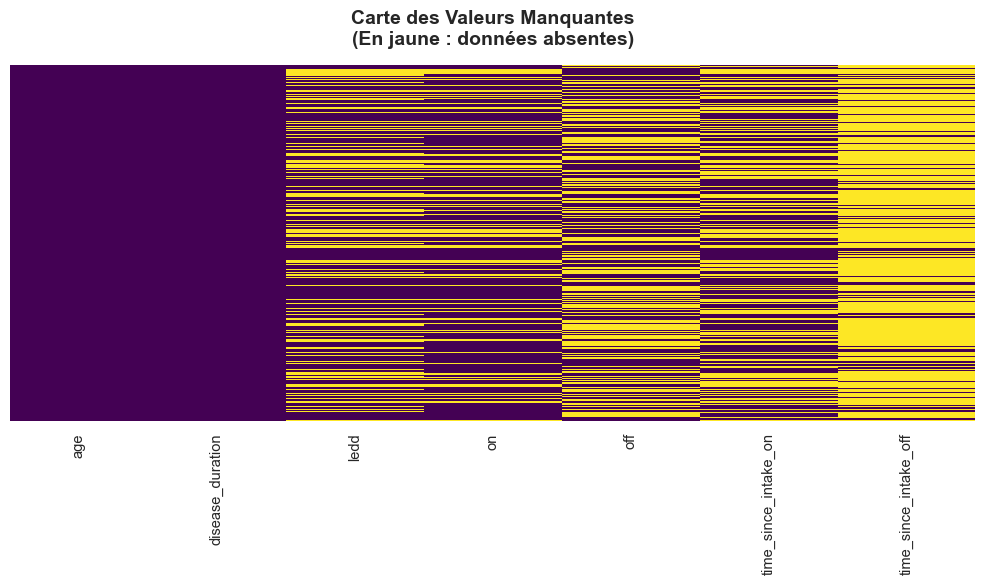


Taux de remplissage (%) :
time_since_intake_off     21.176915
time_since_intake_on      53.347841
off                       57.903351
ledd                      62.964229
on                        70.039386
disease_duration         100.000000
age                      100.000000


In [3]:
colonnes_cliniques = [
    'age', 'disease_duration', 'ledd',
    'on', 'off', 'time_since_intake_on', 'time_since_intake_off'
]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df_eda[colonnes_cliniques].isnull(),
    cbar=False,
    cmap='viridis',
    yticklabels=False,
    ax=ax
)
ax.set_title(
    "Carte des Valeurs Manquantes\n(En jaune : données absentes)",
    fontsize=14, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

# Taux de remplissage par colonne
taux = df_eda[colonnes_cliniques].notna().mean() * 100
print("\nTaux de remplissage (%) :")
print(taux.sort_values().to_string())

### 1.2 — Défi n°2 : Hétérogénéité des Trajectoires Patients

Chaque ligne colorée (un patient) a une **pente** différente.
Le modèle doit comprendre cette dynamique individuelle — c'est la raison
du calcul des pentes (`p_off_slope`) dans `feature_engineering.py`.

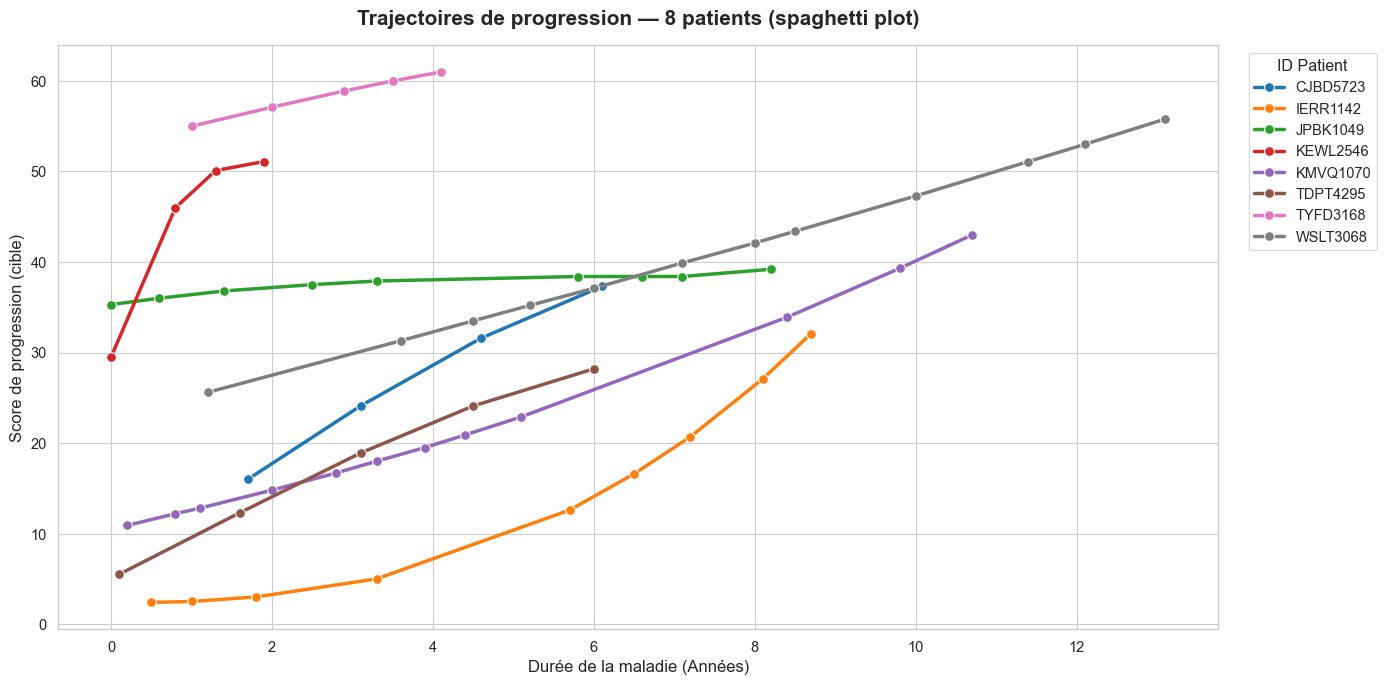

In [4]:
# 8 patients avec au moins 4 visites (sélection reproductible)
rng = np.random.default_rng(seed=42)
patients_longs = (
    df_eda['patient_id'].value_counts()
    .loc[lambda s: s >= 4].index
)
patients_sample = rng.choice(patients_longs, 8, replace=False)

df_sample = (
    df_eda[df_eda['patient_id'].isin(patients_sample)]
    .sort_values(['patient_id', 'disease_duration'])
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(
    data=df_sample,
    x='disease_duration', y='target',
    hue='patient_id',
    marker='o', linewidth=2.5, markersize=7,
    palette='tab10', ax=ax
)
ax.set_title(
    "Trajectoires de progression — 8 patients (spaghetti plot)",
    fontsize=15, fontweight='bold', pad=15
)
ax.set_xlabel("Durée de la maladie (Années)", fontsize=12)
ax.set_ylabel("Score de progression (cible)", fontsize=12)
ax.legend(title='ID Patient', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 1.3 — Défi n°3 : Distribution Asymétrique de la Cible

La distribution brute de `target` est asymétrique avec une queue droite prononcée.
La transformation `log1p` tasse ces extrêmes et stabilise la RMSE.

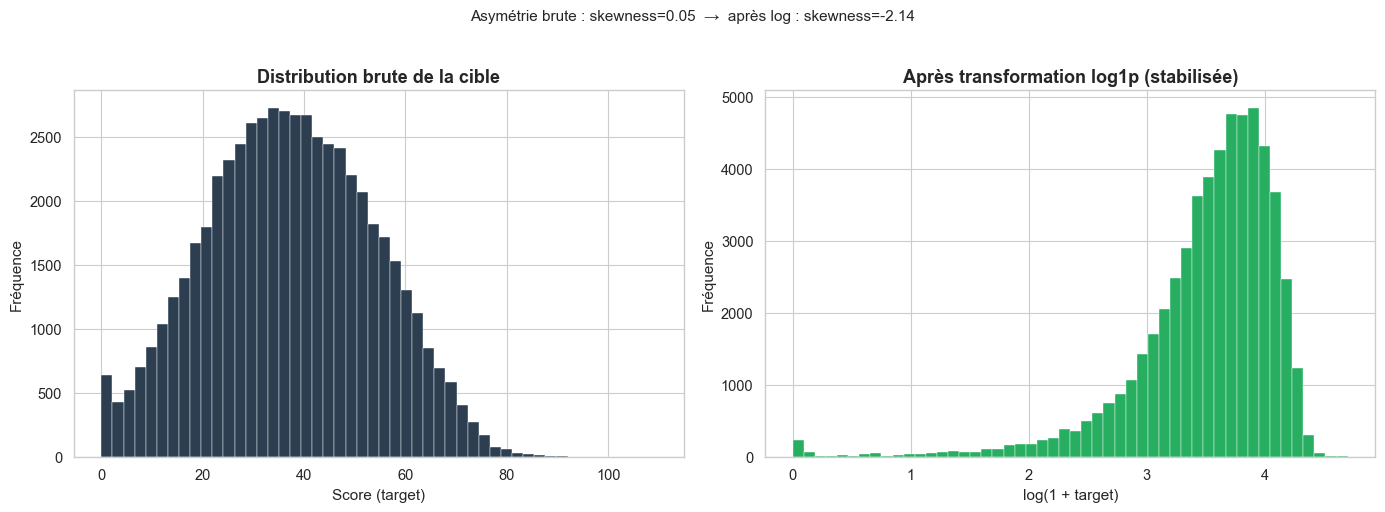

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_raw = df_eda['target'].dropna()

# Distribution brute
axes[0].hist(y_raw, bins=50, color='#2c3e50', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution brute de la cible', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score (target)', fontsize=11)
axes[0].set_ylabel('Fréquence', fontsize=11)

# Distribution log-transformée
axes[1].hist(np.log1p(y_raw), bins=50, color='#27ae60', edgecolor='white', linewidth=0.3)
axes[1].set_title('Après transformation log1p (stabilisée)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + target)', fontsize=11)
axes[1].set_ylabel('Fréquence', fontsize=11)

plt.suptitle(
    f"Asymétrie brute : skewness={y_raw.skew():.2f}  →  "
    f"après log : skewness={np.log1p(y_raw).skew():.2f}",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

### 1.4 — Matrice de Corrélation des Variables Cliniques

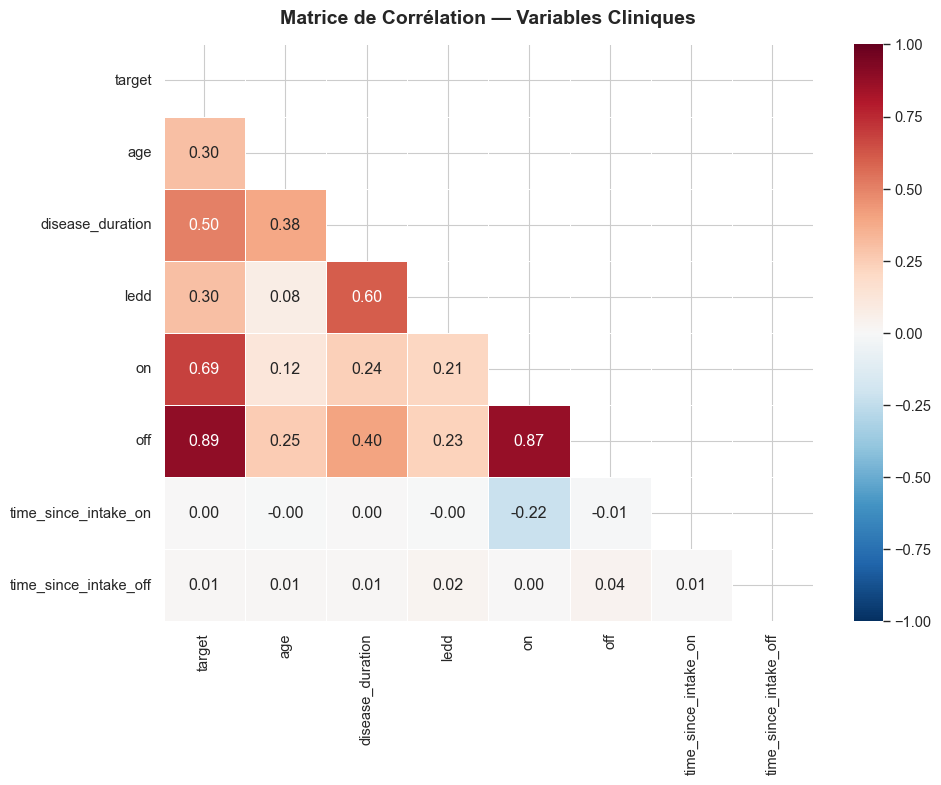

In [6]:
cols_corr = [
    'target', 'age', 'disease_duration', 'ledd',
    'on', 'off', 'time_since_intake_on', 'time_since_intake_off'
]
corr_matrix = df_eda[cols_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title(
    "Matrice de Corrélation — Variables Cliniques",
    fontsize=14, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

---
## PARTIE 2 — Exécution du Pipeline

Un seul appel — `run_training_pipeline()` — enchaîne :
- Ingestion & fusion → `data_preprocessing.py`
- Imputation, PK/PD, lags/leads → `feature_engineering.py`
- Entraînement GroupKFold (HistGBM + LightGBM + XGBoost) → `pipeline.py`
- Calcul du score sMAPE + audit clinique → `metrics.py`

In [7]:
results = run_training_pipeline()

  PIPELINE — Progression de Parkinson

[1/5] Ingestion des données...
[load_datasets] Train : 55,603 visites | Test : 23,672 visites | Patients train : 6971
[merge_molecular_data] Table unifiée : 79,275 lignes — 6971 patients train, 2988 patients test.

[2/5] Imputation et encodage...
[impute_missing_values] disease_duration : 5.9 ans (moy) | ledd_f : 629 mg (moy)

[3/5] Ingénierie des biomarqueurs...
[aggregate_biomarkers] 50 features générées.

[4/5] Construction des matrices (X, y)...
[build_training_matrix] X_tr : (55603, 50) | X_te : (23672, 50) | Cible train — min=0.0, max=109.5, moy=37.3

[5/5] Entraînement — GroupKFold (k=5)...
    Fold 1/5 ✓
    Fold 2/5 ✓
    Fold 3/5 ✓
    Fold 4/5 ✓
    Fold 5/5 ✓

  RMSE OOF      : 3.7416
  MAE  OOF      : 2.6852
  sMAPE         : 9.12%
  Fiabilité (±5pt) : 84.9%


In [8]:
# Affichage synthétique des métriques
metrics = results['metrics']

print("┌─────────────────────────────────────────────────────────┐")
print("│              MÉTRIQUES OOF — Ensemble final             │")
print("├─────────────────────────────────────────────────────────┤")
print(f"│  RMSE           : {metrics['rmse']:>10.4f}                       │")
print(f"│  MAE            : {metrics['mae']:>10.4f}  points moteurs         │")
print(f"│  sMAPE          : {metrics['smape']:>9.2f}%                       │")
print(f"│  Fiabilité ±5pt : {metrics['taux_fiabilite']:>9.1f}%  dans la marge humaine  │")
print("└─────────────────────────────────────────────────────────┘")

┌─────────────────────────────────────────────────────────┐
│              MÉTRIQUES OOF — Ensemble final             │
├─────────────────────────────────────────────────────────┤
│  RMSE           :     3.7416                       │
│  MAE            :     2.6852  points moteurs         │
│  sMAPE          :      9.12%                       │
│  Fiabilité ±5pt :      84.9%  dans la marge humaine  │
└─────────────────────────────────────────────────────────┘


---
## PARTIE 3 — Interprétabilité du Modèle (XAI)

### 3.1 — Importance des Features (Feature Importance LightGBM)

On récupère X_tr depuis les résultats du pipeline pour entraîner
un modèle final interprétable (gain-based importance).

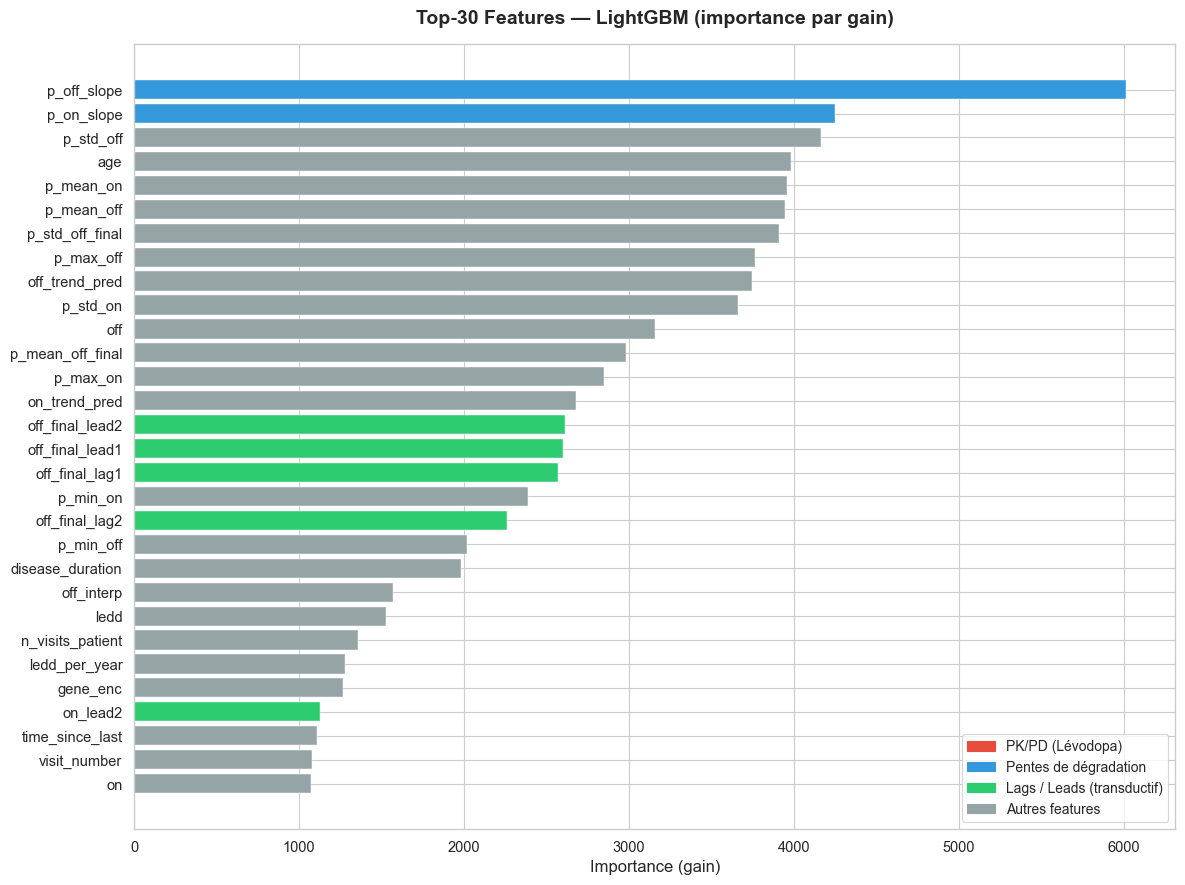

In [9]:
import lightgbm as lgb
from src.config import MODEL_PARAMS

X_tr   = results['X_tr']
y_true = results['y_true']

# Entraînement d'un modèle LightGBM final (sur tout le train) pour l'XAI
lgb_xai = lgb.LGBMRegressor(**MODEL_PARAMS['lgb'])
lgb_xai.fit(X_tr, np.log1p(y_true))

# Importance par gain (signal le plus robuste)
importance_df = (
    pd.DataFrame({
        'feature':    X_tr.columns,
        'importance': lgb_xai.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(12, 9))
colors = ['#e74c3c' if 'pkpd' in f else '#3498db' if 'slope' in f
          else '#2ecc71' if 'lag' in f or 'lead' in f
          else '#95a5a6'
          for f in importance_df['feature']]

ax.barh(
    importance_df['feature'],
    importance_df['importance'],
    color=colors, edgecolor='white', linewidth=0.3
)
ax.invert_yaxis()
ax.set_title(
    "Top-30 Features — LightGBM (importance par gain)",
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Importance (gain)', fontsize=12)

# Légende des couleurs
from matplotlib.patches import Patch
legend = [
    Patch(color='#e74c3c', label='PK/PD (Lévodopa)'),
    Patch(color='#3498db', label='Pentes de dégradation'),
    Patch(color='#2ecc71', label='Lags / Leads (transductif)'),
    Patch(color='#95a5a6', label='Autres features'),
]
ax.legend(handles=legend, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### 3.2 — Audit Clinique Visuel

**Graphique A** — Prédictions vs Réalité avec corridor d'acceptabilité (±5 pts).  
**Graphique B** — Distribution des erreurs par stade de la maladie.

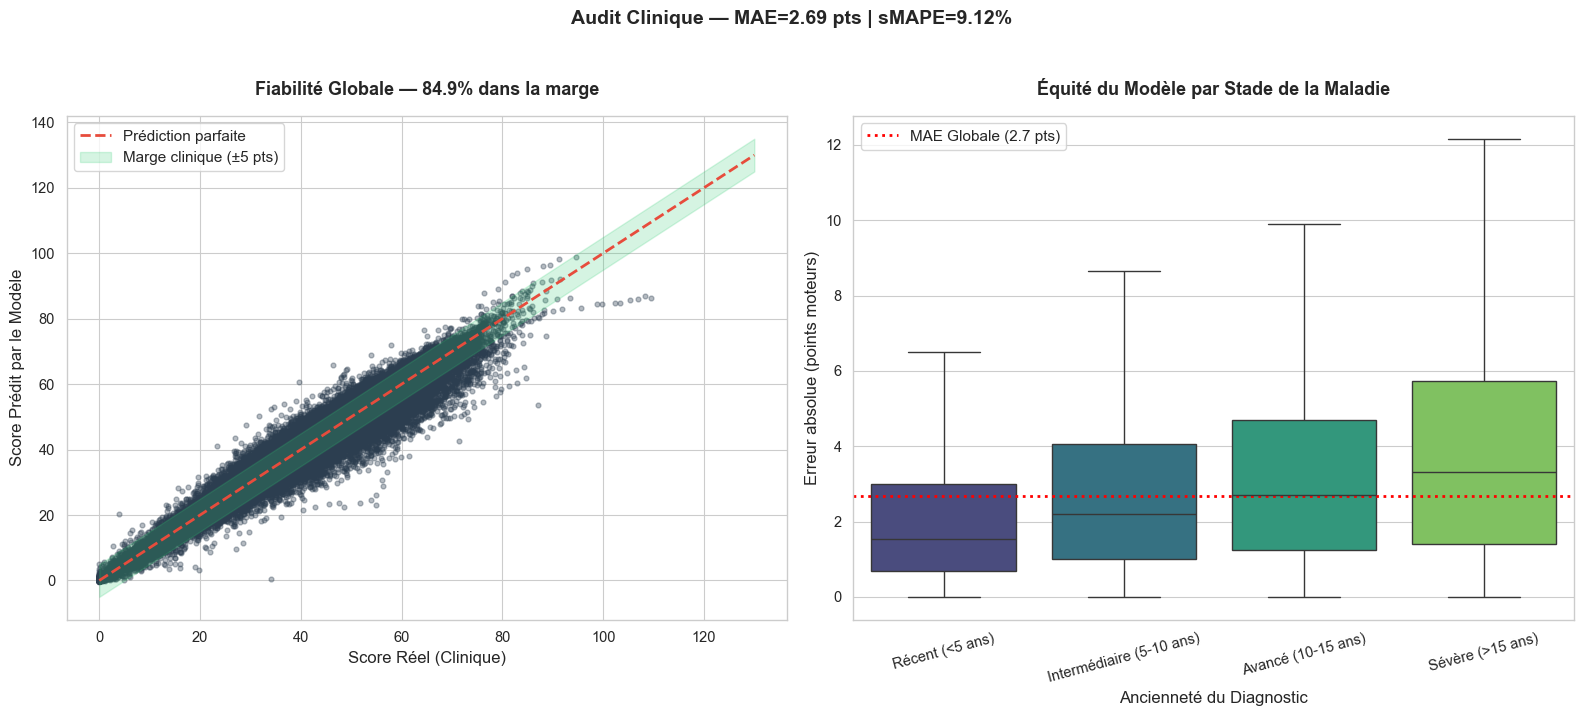

In [10]:
oof_preds    = results['oof_preds']
y_true_arr   = np.asarray(results['y_true'])
df_tr_meta   = results['df_train_meta'].reset_index(drop=True)

df_audit = pd.DataFrame({
    'Vrai_Score':      y_true_arr,
    'Prediction':      oof_preds,
    'Erreur_Absolue':  np.abs(y_true_arr - oof_preds),
    'Duree_Maladie':   df_tr_meta['disease_duration'].values,
})

# Segmentation par stade
bins   = [-1, 5, 10, 15, 100]
labels = ['Récent (<5 ans)', 'Intermédiaire (5-10 ans)', 'Avancé (10-15 ans)', 'Sévère (>15 ans)']
df_audit['Stade'] = pd.cut(df_audit['Duree_Maladie'], bins=bins, labels=labels)

mae_global = metrics['mae']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style='whitegrid')

# ---- Graphique A : Prédictions vs Réalité --------------------------------
axes[0].scatter(
    df_audit['Vrai_Score'], df_audit['Prediction'],
    alpha=0.35, color='#2c3e50', s=12
)
axes[0].plot([0, 130], [0, 130], color='#e74c3c', linestyle='--', linewidth=2,
             label='Prédiction parfaite')
axes[0].fill_between(
    [0, 130], [-5, 125], [5, 135],
    color='#2ecc71', alpha=0.2,
    label=f'Marge clinique (±{CLINICAL_MARGIN:.0f} pts)'
)
axes[0].set_title(
    f"Fiabilité Globale — {metrics['taux_fiabilite']:.1f}% dans la marge",
    fontsize=13, fontweight='bold', pad=15
)
axes[0].set_xlabel('Score Réel (Clinique)', fontsize=12)
axes[0].set_ylabel('Score Prédit par le Modèle', fontsize=12)
axes[0].legend(loc='upper left')

# ---- Graphique B : Erreur par stade de la maladie ------------------------
sns.boxplot(
    data=df_audit, x='Stade', y='Erreur_Absolue',
    ax=axes[1], palette='viridis', showfliers=False
)
axes[1].axhline(
    y=mae_global, color='red', linestyle=':', linewidth=2,
    label=f'MAE Globale ({mae_global:.1f} pts)'
)
axes[1].set_title(
    "Équité du Modèle par Stade de la Maladie",
    fontsize=13, fontweight='bold', pad=15
)
axes[1].set_xlabel('Ancienneté du Diagnostic', fontsize=12)
axes[1].set_ylabel('Erreur absolue (points moteurs)', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.suptitle(
    f"Audit Clinique — MAE={mae_global:.2f} pts | sMAPE={metrics['smape']:.2f}%",
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Conclusion

| Pilier | Implémentation |
|---|---|
| **Réalité clinique (PK/PD)** | `feature_engineering._compute_pkpd()` — modèle de décroissance de la Lévodopa |
| **Ingénierie transductive** | `feature_engineering.aggregate_biomarkers()` — pentes, lags, leads |
| **Stabilité numérique** | `pipeline.run_training_pipeline()` — transformation log1p sur la cible |
| **Intelligence collective** | `models.get_base_estimators()` — consortium HistGBM + LightGBM + XGBoost |
| **Validation clinique** | `metrics.clinical_audit()` — MAE, sMAPE, taux de fiabilité |

---
*Notebook refactorisé selon le principe de Séparation des Responsabilités (SoC).*
*Toute la logique métier réside dans `src/` — ce fichier est uniquement un orchestrateur visuel.*